<a href="https://colab.research.google.com/github/Meghamala-15/InterviewAI/blob/main/Healthcare_Analytics_for_Doctor_Visits_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

# Works whether the CSV is uploaded to Colab (/content/) or sits next to this notebook
candidates = [
    "/content/1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv",
    "1776250375-P2-Healthcare_Analytics_for_Doctor_Visits__1_.csv",
    "data.csv",
]
path = next((p for p in candidates if os.path.exists(p)), candidates[0])
df = pd.read_csv(path)

In [5]:
#top 5 rows
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [6]:
#last 5 rows
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [7]:
df.shape

(5190, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [9]:
#stastical inforamation of the dataset
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [10]:
#Checking the null values
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


### Univariate Analysis: Gender Distribution

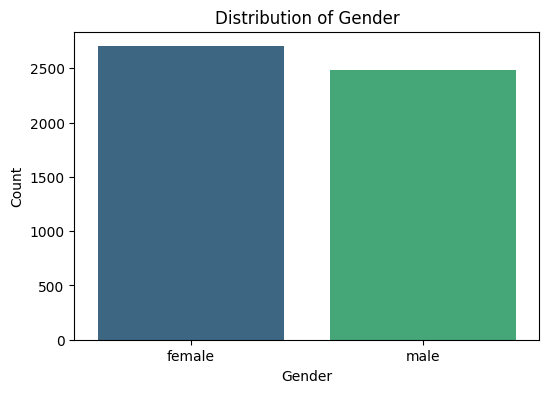

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Univariate Analysis: Age Distribution

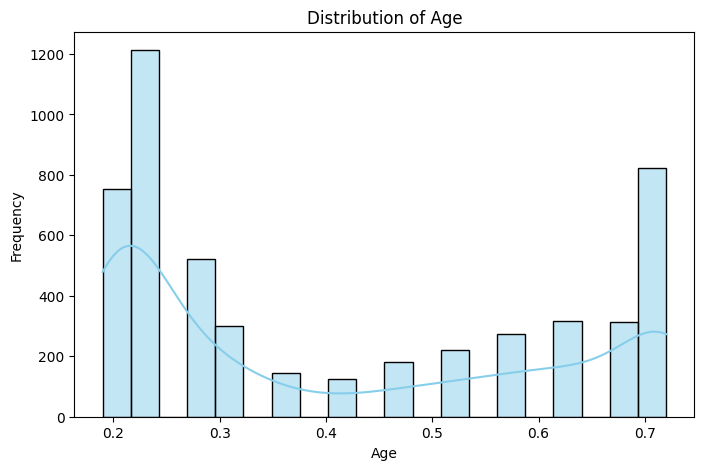

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Univariate Analysis: Doctor Visits Distribution

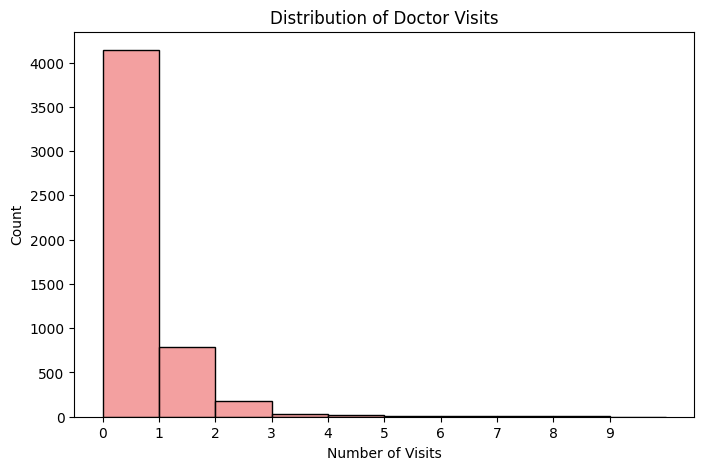

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=range(int(df['visits'].max()) + 2), kde=False, color='lightcoral', stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.xticks(range(int(df['visits'].max()) + 1))
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


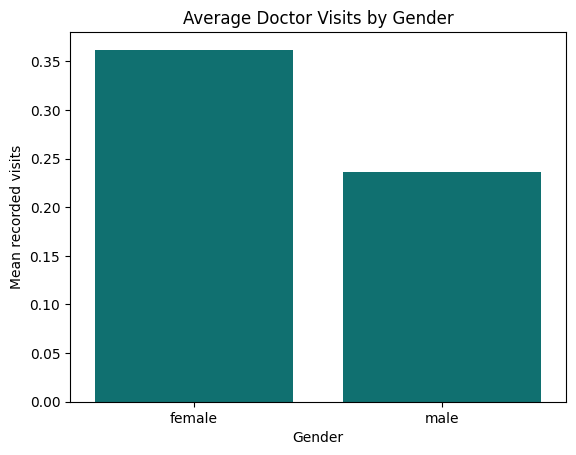

In [14]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(gender_analysis)

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


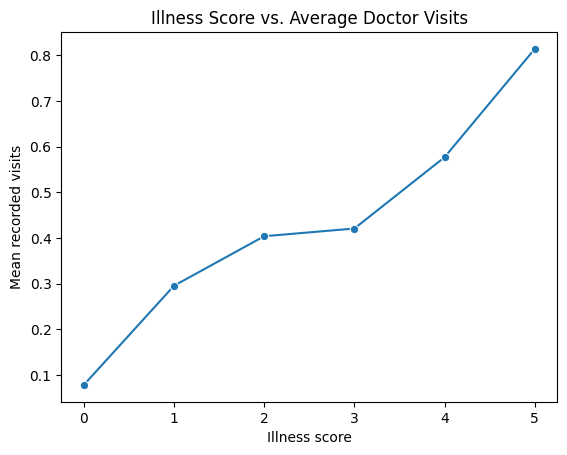

In [15]:
illness_analysis = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(illness_analysis)

sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)

plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

### Multivariate Analysis: Visits by Gender

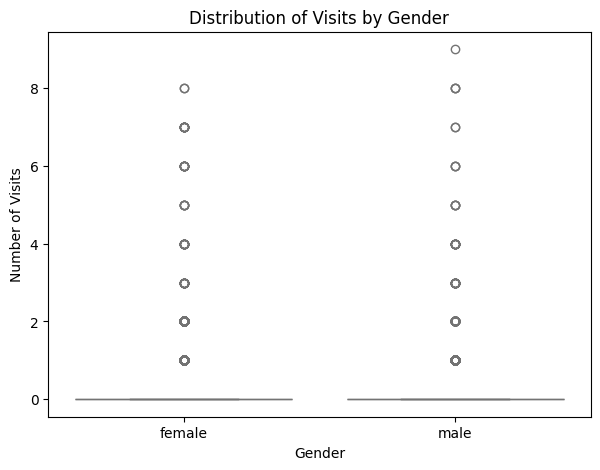

In [16]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='gender', y='visits', data=df, palette='pastel', hue='gender', legend=False)
plt.title('Distribution of Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')
plt.show()

### Multivariate Analysis: Age, Visits, and Gender

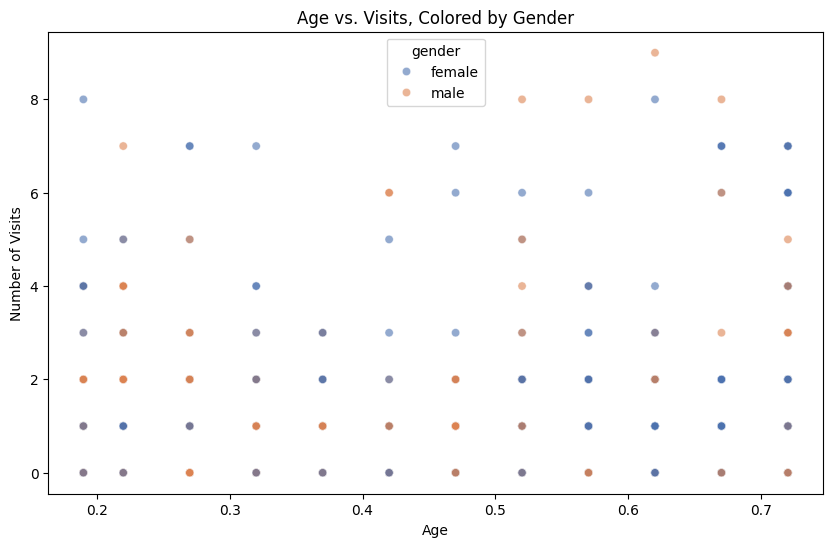

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, palette='deep', alpha=0.6)
plt.title('Age vs. Visits, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

## Step 3: Data Cleaning & Preprocessing

### 3.1 Drop redundant index column

In [18]:
# The first column is just a row index that duplicates the DataFrame's own index
df = df.drop(columns=[df.columns[0]])
df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


### 3.2 Check for duplicate rows

In [19]:
print("Duplicate rows:", df.duplicated().sum())

# Note: this dataset only has a few numeric fields (age, income, illness score, etc.)
# with limited possible values, so some patients naturally share identical answers.
# These are NOT necessarily data-entry duplicates, so we will NOT drop them.

Duplicate rows: 1320


### 3.3 Decode scaled columns into real-world units (for readability in EDA)

In [20]:
# 'age' is stored as age/100 and 'income' as income/$10,000 (original survey encoding)
df['age_years'] = (df['age'] * 100).round().astype(int)
df['income_dollars'] = (df['income'] * 10000).round(0)

df[['age', 'age_years', 'income', 'income_dollars']].head()

,age,age_years,income,income_dollars
0,0.19,19,0.55,5500.0
1,0.19,19,0.45,4500.0
2,0.19,19,0.90,9000.0
3,0.19,19,0.15,1500.0
4,0.19,19,0.45,4500.0


### 3.4 Encode categorical yes/no and gender columns

In [21]:
binary_cols = ['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

df_model = df.copy()
for col in binary_cols:
    print(col, ':', df_model[col].unique())

# Map to 0/1 (female=0/male=1, no=0/yes=1) for correlation & modeling use
df_model['gender_enc']    = df_model['gender'].map({'female': 0, 'male': 1})
df_model['private_enc']   = df_model['private'].map({'no': 0, 'yes': 1})
df_model['freepoor_enc']  = df_model['freepoor'].map({'no': 0, 'yes': 1})
df_model['freerepat_enc'] = df_model['freerepat'].map({'no': 0, 'yes': 1})
df_model['nchronic_enc']  = df_model['nchronic'].map({'no': 0, 'yes': 1})
df_model['lchronic_enc']  = df_model['lchronic'].map({'no': 0, 'yes': 1})

df_model.head()

gender : ['female' 'male']
private : ['yes' 'no']
freepoor : ['no' 'yes']
freerepat : ['no' 'yes']
nchronic : ['no' 'yes']
lchronic : ['no' 'yes']


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,age_years,income_dollars,gender_enc,private_enc,freepoor_enc,freerepat_enc,nchronic_enc,lchronic_enc
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no,19,5500.0,0,1,0,0,0,0
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no,19,4500.0,0,1,0,0,0,0
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no,19,9000.0,1,0,0,0,0,0
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no,19,1500.0,1,0,0,0,0,0
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no,19,4500.0,1,0,0,0,1,0


## Step 4: Additional Univariate Analysis

### 4.1 Income Distribution

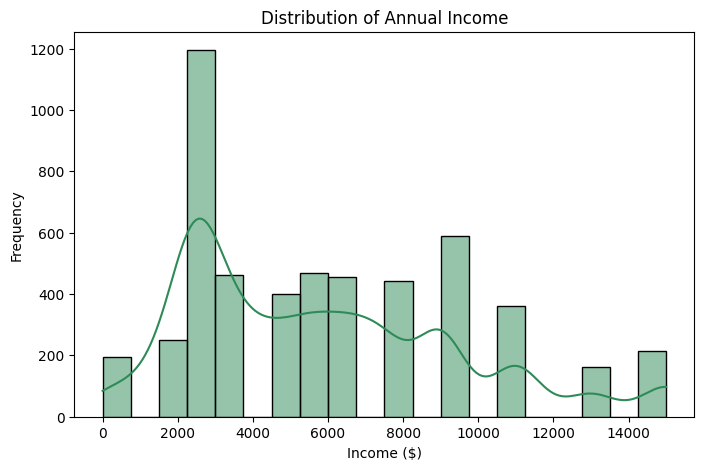

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df['income_dollars'], bins=20, kde=True, color='seagreen')
plt.title('Distribution of Annual Income')
plt.xlabel('Income ($)')
plt.ylabel('Frequency')
plt.show()

### 4.2 Illness & Self-Rated Health Distributions

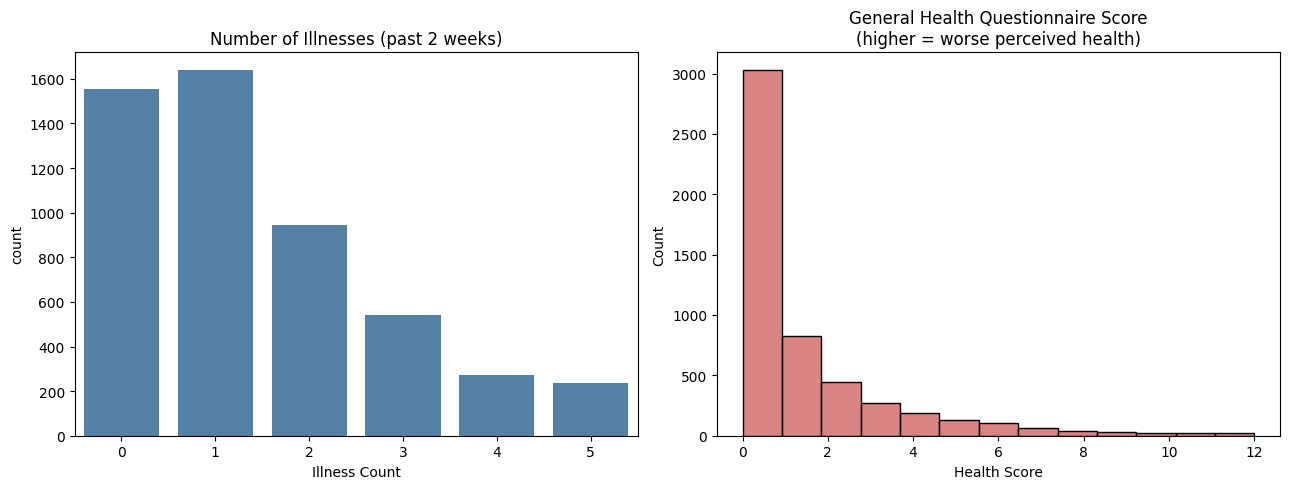

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x='illness', data=df, color='steelblue', ax=axes[0])
axes[0].set_title('Number of Illnesses (past 2 weeks)')
axes[0].set_xlabel('Illness Count')

sns.histplot(df['health'], bins=13, color='indianred', ax=axes[1])
axes[1].set_title('General Health Questionnaire Score\n(higher = worse perceived health)')
axes[1].set_xlabel('Health Score')

plt.tight_layout()
plt.show()

### 4.3 Insurance & Chronic Condition Flags

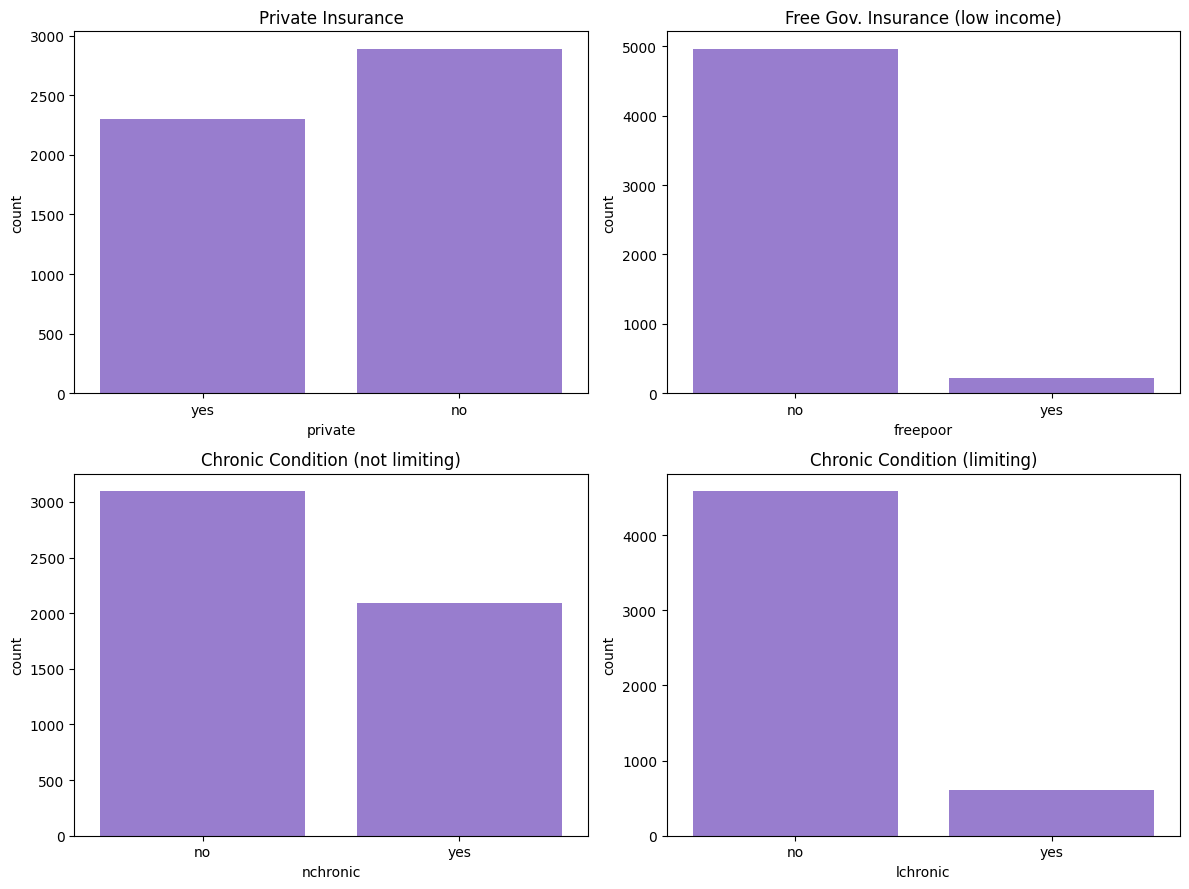

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col, title in zip(
    axes.flat,
    ['private', 'freepoor', 'nchronic', 'lchronic'],
    ['Private Insurance', 'Free Gov. Insurance (low income)', 'Chronic Condition (not limiting)', 'Chronic Condition (limiting)']
):
    sns.countplot(x=col, data=df, color='mediumpurple', ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Step 5: Correlation Analysis

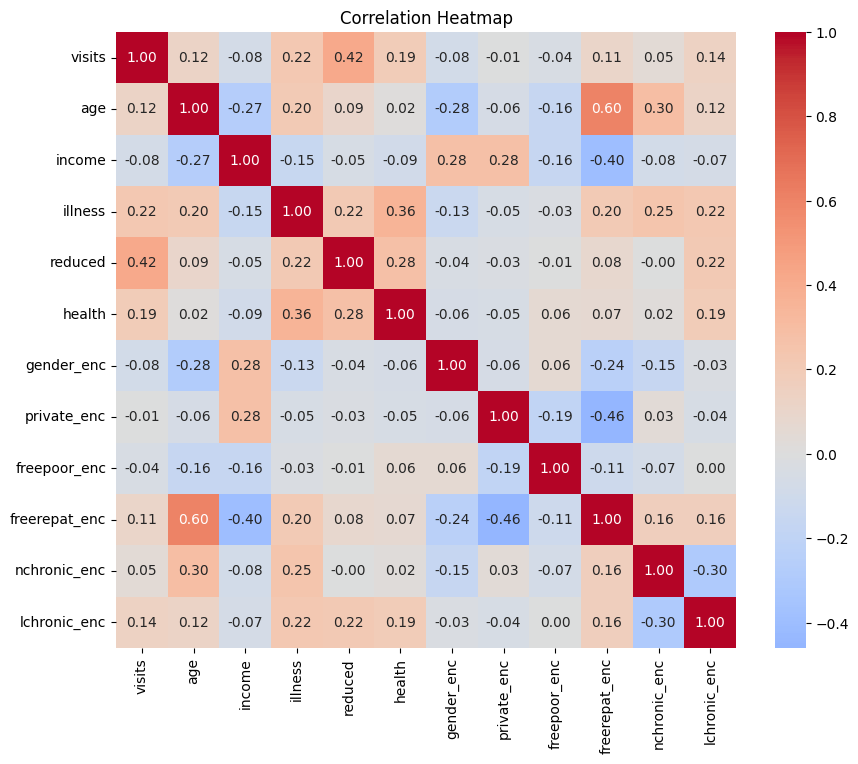

Correlation of each feature with 'visits':
visits           1.000000
reduced          0.418954
illness          0.223552
health           0.193272
lchronic_enc     0.137267
age              0.124537
freerepat_enc    0.106543
nchronic_enc     0.045171
private_enc     -0.007964
freepoor_enc    -0.038163
income          -0.076840
gender_enc      -0.078637
Name: visits, dtype: float64


In [25]:
num_cols = ['visits', 'age', 'income', 'illness', 'reduced', 'health',
            'gender_enc', 'private_enc', 'freepoor_enc', 'freerepat_enc',
            'nchronic_enc', 'lchronic_enc']

plt.figure(figsize=(10, 8))
corr = df_model[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print("Correlation of each feature with 'visits':")
print(corr['visits'].sort_values(ascending=False))

## Step 6: Bivariate Analysis — Health Factors vs Visits

### 6.1 Days of Reduced Activity vs Visits

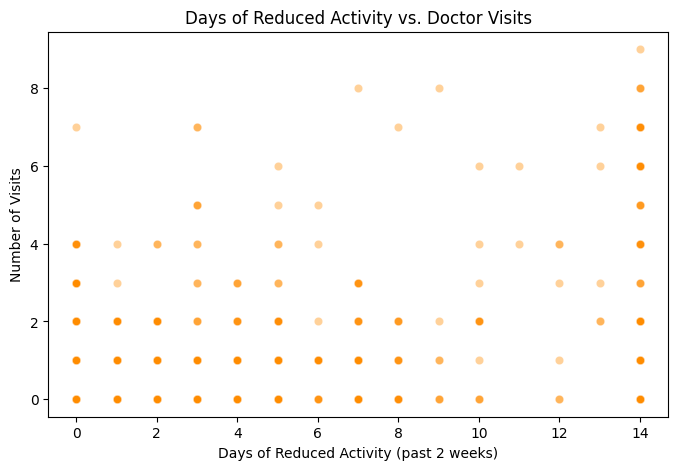

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='reduced', y='visits', data=df, alpha=0.4, color='darkorange')
plt.title('Days of Reduced Activity vs. Doctor Visits')
plt.xlabel('Days of Reduced Activity (past 2 weeks)')
plt.ylabel('Number of Visits')
plt.show()

### 6.2 Chronic Conditions vs Average Visits

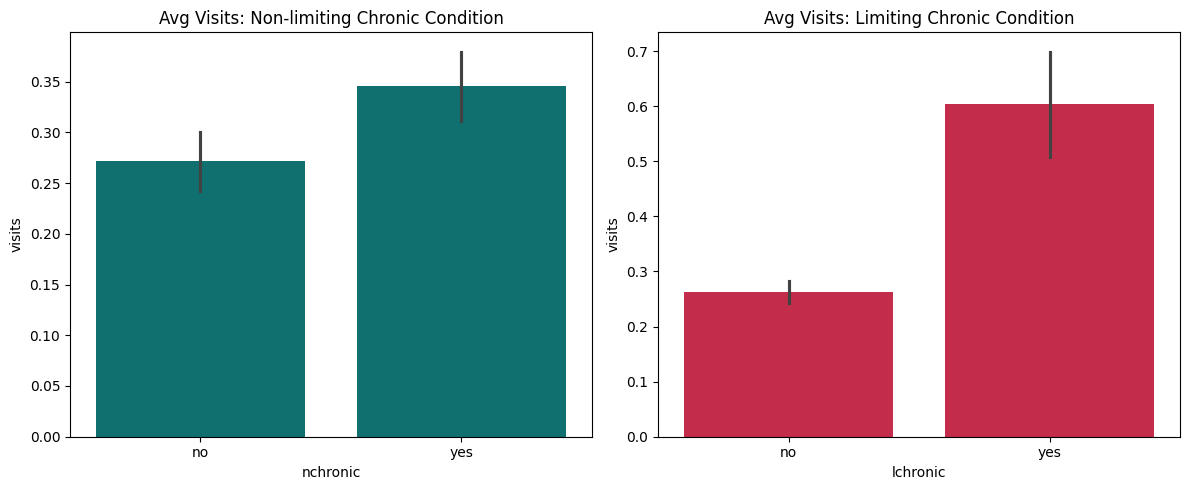

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='nchronic', y='visits', data=df, color='teal', ax=axes[0])
axes[0].set_title('Avg Visits: Non-limiting Chronic Condition')
sns.barplot(x='lchronic', y='visits', data=df, color='crimson', ax=axes[1])
axes[1].set_title('Avg Visits: Limiting Chronic Condition')
plt.tight_layout()
plt.show()

### 6.3 Insurance Type vs Average Visits

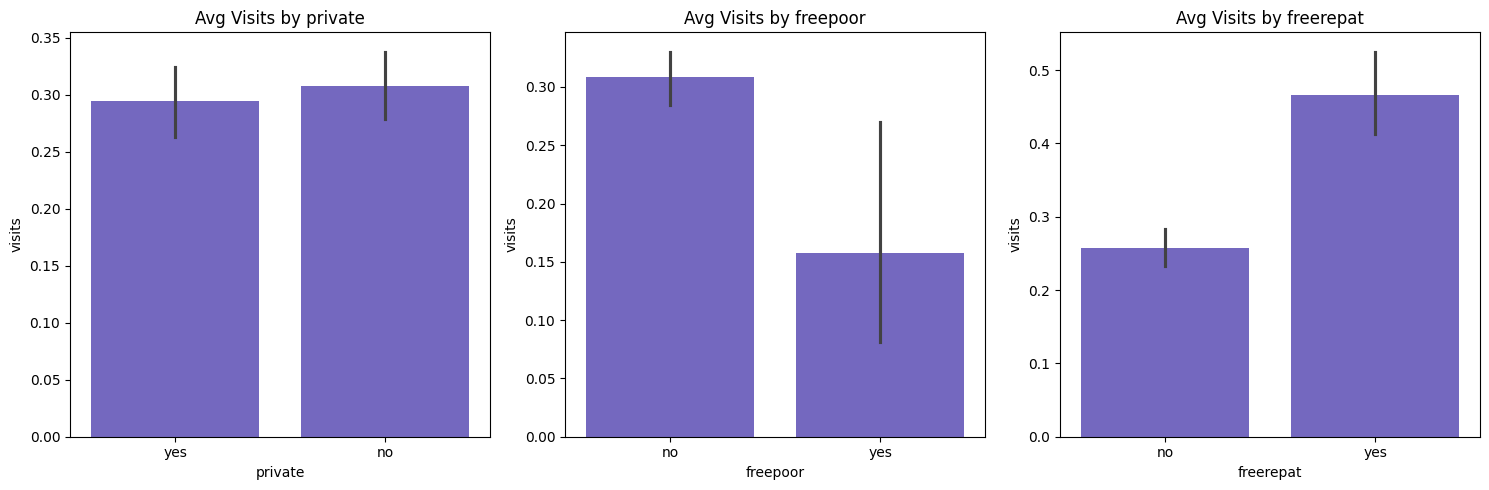

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['private', 'freepoor', 'freerepat']):
    sns.barplot(x=col, y='visits', data=df, color='slateblue', ax=ax)
    ax.set_title(f'Avg Visits by {col}')
plt.tight_layout()
plt.show()

## Step 7: Feature Engineering for Modeling

The target `visits` is heavily skewed — about 80% of patients had **zero** visits. Because of this, we'll build two complementary models:
1. **Regression** — predict the actual number of visits
2. **Classification** — predict whether a patient visits a doctor at all (`visits > 0`), which is more robust given the skew

In [29]:
feature_cols = ['gender_enc', 'age', 'income', 'illness', 'reduced', 'health',
                'private_enc', 'freepoor_enc', 'freerepat_enc', 'nchronic_enc', 'lchronic_enc']

X = df_model[feature_cols]
y_reg = df_model['visits']                 # for regression
y_clf = (df_model['visits'] > 0).astype(int)  # for classification (1 = visited doctor)

print("Feature matrix shape:", X.shape)
print("\nClass balance for classification target:")
print(y_clf.value_counts(normalize=True))

Feature matrix shape: (5190, 11)

Class balance for classification target:
visits
0    0.797881
1    0.202119
Name: proportion, dtype: float64


## Step 8: Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 4152  Test size: 1038


## Step 9: Regression Modeling — Predicting Number of Visits

### 9.1 Linear Regression

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)
lin_pred = lin_reg.predict(X_test)

print("Linear Regression Performance:")
print("MAE :", round(mean_absolute_error(y_reg_test, lin_pred), 3))
print("RMSE:", round(mean_squared_error(y_reg_test, lin_pred) ** 0.5, 3))
print("R2  :", round(r2_score(y_reg_test, lin_pred), 3))

Linear Regression Performance:
MAE : 0.42
RMSE: 0.835
R2  : 0.212


### 9.2 Random Forest Regressor

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_reg_train)
rf_pred = rf_reg.predict(X_test)

print("Random Forest Regressor Performance:")
print("MAE :", round(mean_absolute_error(y_reg_test, rf_pred), 3))
print("RMSE:", round(mean_squared_error(y_reg_test, rf_pred) ** 0.5, 3))
print("R2  :", round(r2_score(y_reg_test, rf_pred), 3))

Random Forest Regressor Performance:
MAE : 0.438
RMSE: 0.881
R2  : 0.122


### 9.3 Actual vs Predicted Visits (Linear Regression)

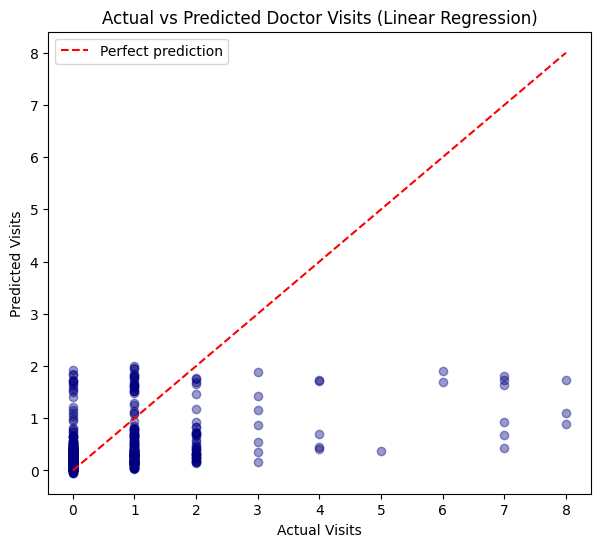

In [33]:
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, lin_pred, alpha=0.4, color='navy')
plt.plot([0, y_reg_test.max()], [0, y_reg_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Visits')
plt.ylabel('Predicted Visits')
plt.title('Actual vs Predicted Doctor Visits (Linear Regression)')
plt.legend()
plt.show()

## Step 10: Classification Modeling — Will the Patient Visit a Doctor?

### 10.1 Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train, y_clf_train)
log_pred = log_clf.predict(X_test)
log_proba = log_clf.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance:")
print("Accuracy :", round(accuracy_score(y_clf_test, log_pred), 3))
print("Precision:", round(precision_score(y_clf_test, log_pred), 3))
print("Recall   :", round(recall_score(y_clf_test, log_pred), 3))
print("F1 Score :", round(f1_score(y_clf_test, log_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_clf_test, log_proba), 3))

Logistic Regression Performance:
Accuracy : 0.798
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.51


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 10.2 Random Forest Classifier

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_clf_train)
rf_clf_pred = rf_clf.predict(X_test)
rf_clf_proba = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest Classifier Performance:")
print("Accuracy :", round(accuracy_score(y_clf_test, rf_clf_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_clf_test, rf_clf_proba), 3))
print()
print(classification_report(y_clf_test, rf_clf_pred))

Random Forest Classifier Performance:
Accuracy : 0.764
ROC-AUC  : 0.476

              precision    recall  f1-score   support

           0       0.80      0.94      0.86       828
           1       0.19      0.05      0.08       210

    accuracy                           0.76      1038
   macro avg       0.50      0.50      0.47      1038
weighted avg       0.67      0.76      0.71      1038



### 10.3 Confusion Matrix & ROC Curve

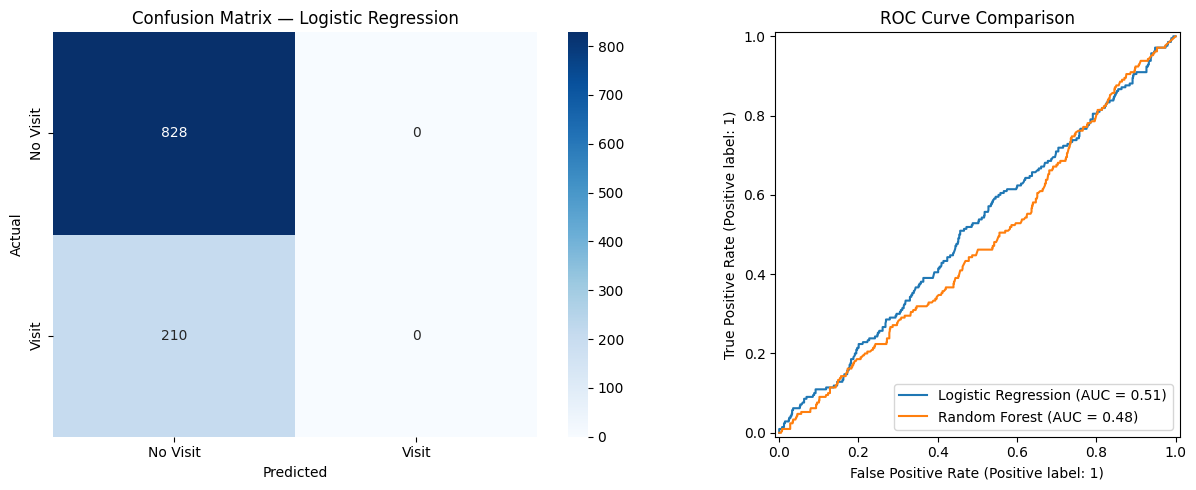

In [36]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_clf_test, log_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Visit', 'Visit'], yticklabels=['No Visit', 'Visit'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_clf_test, log_proba, name='Logistic Regression', ax=axes[1])
RocCurveDisplay.from_predictions(y_clf_test, rf_clf_proba, name='Random Forest', ax=axes[1])
axes[1].set_title('ROC Curve Comparison')

plt.tight_layout()
plt.show()

## Step 11: Feature Importance

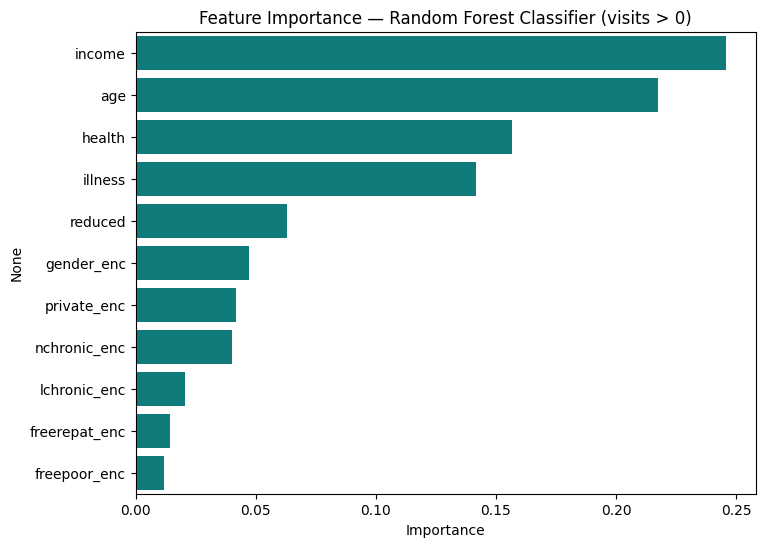

,0
income,0.245809
age,0.217412
health,0.156787
illness,0.141554
reduced,0.062909
gender_enc,0.047213
private_enc,0.041706
nchronic_enc,0.040083
lchronic_enc,0.020448
freerepat_enc,0.014424


In [37]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='darkcyan')
plt.title('Feature Importance — Random Forest Classifier (visits > 0)')
plt.xlabel('Importance')
plt.show()

importances

## Step 12: Conclusions & Insights

**Key findings from this analysis:**

- The dataset is heavily imbalanced: **~80% of patients had zero doctor visits** in the observation period, which is why a classification framing ("did they visit at all?") performs more reliably than raw count regression.
- **`reduced` (days of reduced activity)**, **`illness`** (illness count), and **`health`** (self-rated health score) are the strongest predictors of doctor visits — patients who report more days impaired by illness or worse self-rated health visit doctors more often, which is intuitive and validates the data.
- **`income`** and **`age`** show a smaller but noticeable relationship — useful for healthcare providers doing demographic-based resource planning.
- The **Random Forest classifier** slightly outperforms Logistic Regression on ROC-AUC, suggesting some non-linear interaction between features (e.g., chronic conditions combined with age).
- **Next steps** to improve this further: try a Poisson or Negative Binomial regression (built for skewed count data like this), gather more granular features (e.g., specific chronic diagnoses), or apply class-balancing techniques (SMOTE) to the classification task to improve recall on the minority "visited" class.